<a href="https://colab.research.google.com/github/ushasri0412/Data-Science-Task/blob/main/TAXI_Pricing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Taxi Trip Pricing**

In [138]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error


In [139]:
#read the file
df=pd.read_csv("/content/taxi_trip_pricing.csv")
df.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180


In [140]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    object 
 2   Day_of_Week            950 non-null    object 
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    object 
 5   Weather                950 non-null    object 
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB


In [141]:
df.describe()

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,951.000000
mean,27.070547,2.476842,3.502989,1.233316,0.292916,62.118116,56.874773
std,19.905300,1.102249,0.870162,0.429816,0.115592,32.154406,40.469791
min,1.230000,1.000000,2.010000,0.500000,0.100000,5.010000,6.126900
25%,12.632500,1.250000,2.730000,0.860000,0.190000,35.882500,33.742650
50%,25.830000,2.000000,3.520000,1.220000,0.290000,61.860000,50.074500
75%,38.405000,3.000000,4.260000,1.610000,0.390000,89.055000,69.099350
max,146.067047,4.000000,5.000000,2.000000,0.500000,119.840000,332.043689


#EDA


In [142]:
df.isnull().sum()

,0
Trip_Distance_km,50
Time_of_Day,50
Day_of_Week,50
Passenger_Count,50
Traffic_Conditions,50
Weather,50
Base_Fare,50
Per_Km_Rate,50
Per_Minute_Rate,50
Trip_Duration_Minutes,50


In [143]:
df.shape

(1000, 11)

In [144]:
df.drop_duplicates()
df.shape

(1000, 11)

In [145]:
#cleaning the data
for col in df.columns:
  if df[col].dtype=='object':
    df[col]=df[col].fillna(df[col].mode()[0])
  elif df[col].dtype in ['float64', 'int64']:
    df[col]=df[col].fillna(df[col].mean())

In [146]:
df.isnull().sum()

,0
Trip_Distance_km,0
Time_of_Day,0
Day_of_Week,0
Passenger_Count,0
Traffic_Conditions,0
Weather,0
Base_Fare,0
Per_Km_Rate,0
Per_Minute_Rate,0
Trip_Duration_Minutes,0


In [147]:
#Label Encoding
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for col in df.columns:
  if df[col].dtype=='object':
    df[col]=le.fit_transform(df[col])

<Axes: xlabel='Trip_Price', ylabel='Count'>

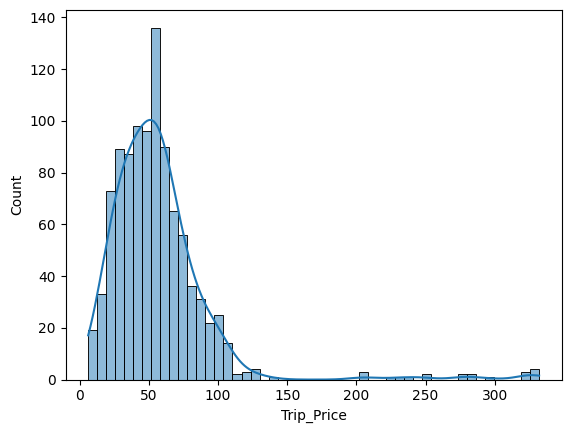

In [148]:
sns.histplot(x="Trip_Price",data=df,kde=True)

<Axes: xlabel='Trip_Distance_km', ylabel='Count'>

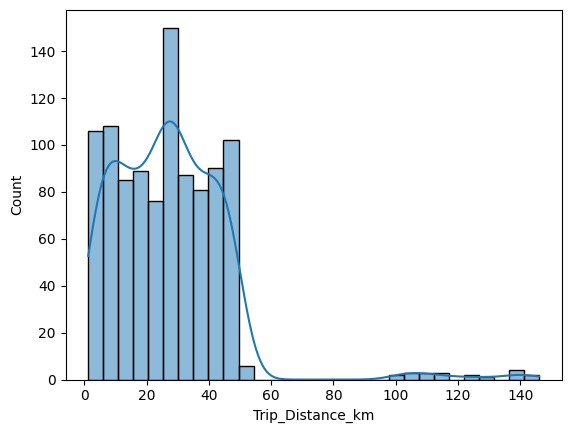

In [149]:
sns.histplot(x="Trip_Distance_km",data=df,kde=True)

<Axes: xlabel='Trip_Duration_Minutes', ylabel='Count'>

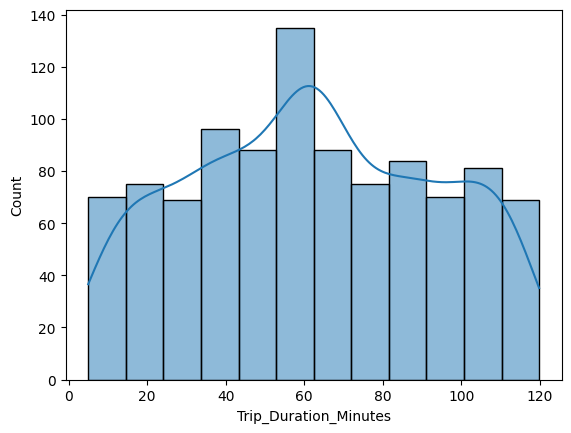

In [150]:
sns.histplot(x="Trip_Duration_Minutes",data=df,kde=True)

<Axes: >

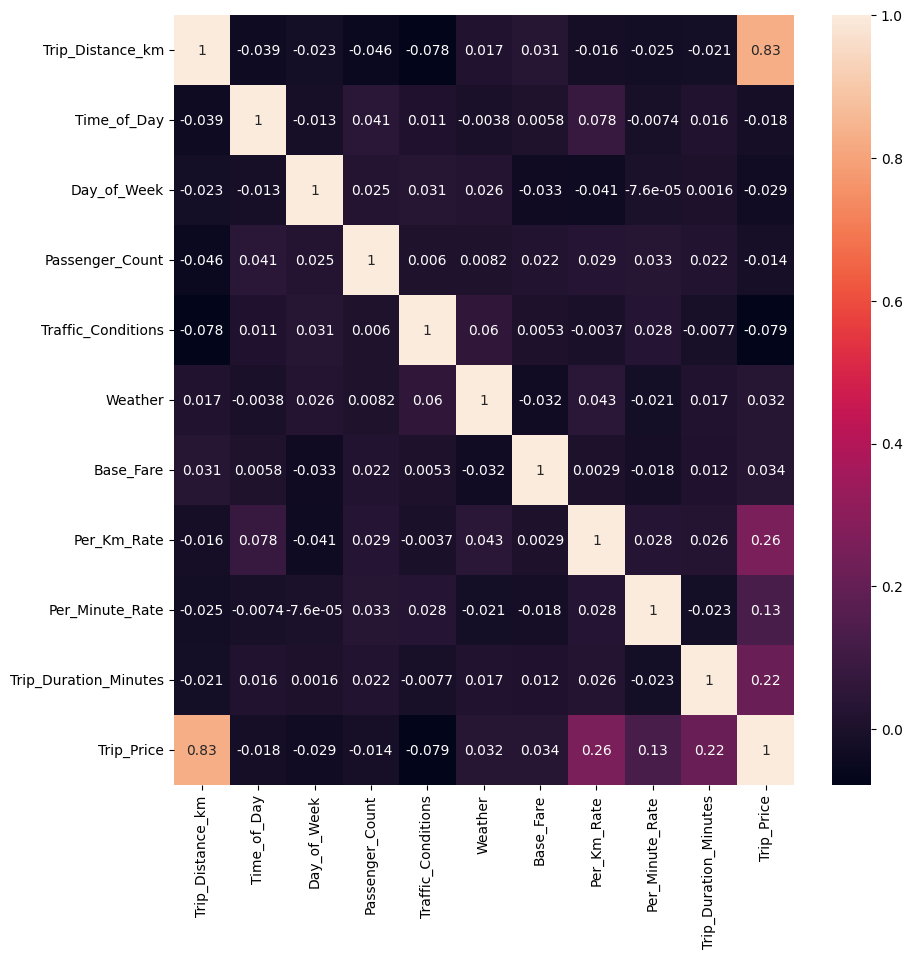

In [151]:
d=df.corr()
plt.figure(figsize=(10,10))
sns.heatmap(d,annot=True)

# Model Training


In [152]:
#Dividing input and output
X=df.drop('Trip_Price',axis=1)
y=df['Trip_Price']

In [153]:
#splitting data into 2 --> training and testing data (70% and 30%)
Xtrain,Xtest,ytrain,ytest=train_test_split(X,y,test_size=0.3, random_state=42)

In [154]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
Xtrain=sc.fit_transform(Xtrain)
Xtest=sc.transform(Xtest)

In [155]:
model=LinearRegression()
model.fit(Xtrain,ytrain)

LinearRegression()

# Model Prediction

In [156]:
y_pred = model.predict(Xtest)
y_pred

array([ 75.73415645,  87.91790572,  65.54347889,  73.05753936,
       118.20711395,  72.30911579,  24.4387527 ,  53.07256557,
        30.79708089,  77.15363765,  74.25684847, 100.94436688,
        74.1884712 ,  26.7375471 ,  -0.43862248,   5.25678968,
        69.65444246,  17.91981602,  22.29316494,  36.68786121,
        78.680496  ,  39.57655235, -24.82427857,  34.20836234,
        43.45665299,  91.61849827,  69.68195189,  43.66408556,
        35.10295088,  92.80102852,  83.62828631,  86.22966245,
        13.95390302, 104.88216805,  39.72219644,  95.45818851,
        23.154912  ,  58.54630031,  25.75311016,  76.54718735,
        51.65308442,  36.95535291,   0.73445402,  32.8623989 ,
        14.0636443 ,  60.54333662,  53.35195089,  45.24174492,
        43.0089822 ,  48.43051734,  63.50181153,   8.92445118,
        84.10107483,  61.03772428,  32.72836284,  69.96146224,
        36.7029903 ,  34.90145877,  60.54642211,  53.4373233 ,
        89.54104056,  71.97402251,  43.81548154,  54.98

# Model Evaluation

In [157]:
#calculating MAE , MSE , And R2 score
print("MAE: " ,mean_absolute_error(ytest,y_pred))
print("MSE: " ,mean_squared_error(ytest,y_pred))
print("R2 Score: ", r2_score(ytest,y_pred))

MAE:  10.394292737413146
MSE:  290.0878977524591
R2 Score:  0.777132495615791


In [158]:
print("Training Efficiency: ",model.score(Xtrain,ytrain))
print("Testing Efficiency: ",model.score(Xtest,ytest))

Training Efficiency:  0.8538835616901412
Testing Efficiency:  0.777132495615791


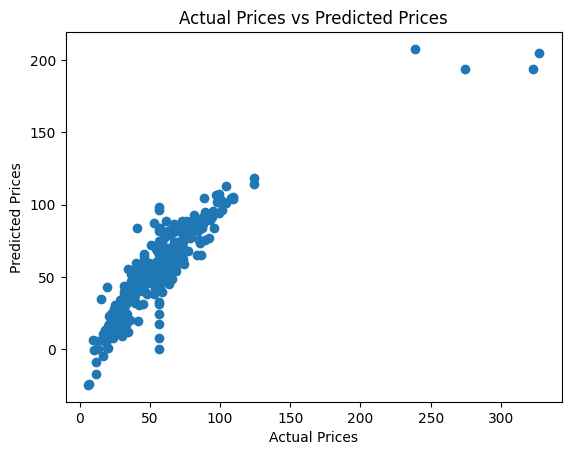

In [159]:
plt.scatter(ytest,y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Prices vs Predicted Prices")
plt.show()

Model is working accurately